<img src="udc1.png" alt="UDC"/>

# Notebook pour la classification d'images(déchets) avec JEPA. 

In [1]:
import outils
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = outils.Load_data.load_object("dataset2.zip")

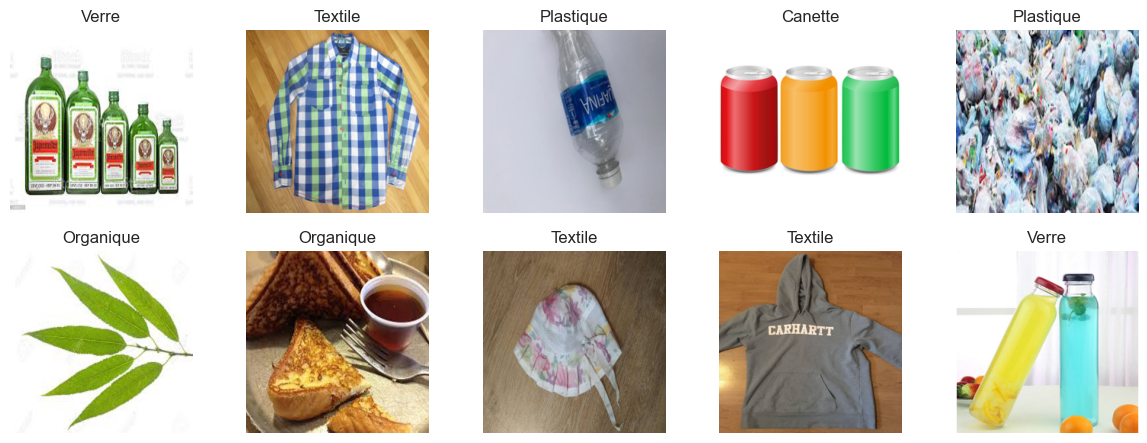

In [3]:
df.plot()

In [4]:
df.reshape(target_shape=(128, 128, 3))

Reshape en batch: 100%|██████████| 380/380 [00:37<00:00, 10.21it/s]


In [5]:
df.encodage()

In [6]:
(X_train, y_train), (X_test, y_test) = df.create_data(test_size=0.2)

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [8]:
train_datagen = ImageDataGenerator(
    rotation_range=35,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.6, 1.4],
    channel_shift_range=30.0,
    fill_mode='nearest',
    rescale=1./255
)


test_datagen =  ImageDataGenerator(rescale= 1. / 255)

In [9]:
train_generator = train_datagen.flow(X_train,y_train,batch_size=16)
test_generator  = test_datagen.flow(X_test,y_test,batch_size=16)

In [10]:
from tensorflow import keras
from keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.optimizers import Adam,SGD,RMSprop
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras.callbacks import LearningRateScheduler,ModelCheckpoint,ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
from tensorflow.keras import layers, regularizers, Model, Input
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.layers import Dense, Dropout, Add, BatchNormalization, Input, Flatten
from tensorflow.keras.applications import InceptionResNetV2

In [22]:
def build_encoder(input_shape=(128, 128, 3), embed_dim=256):
    inputs = Input(shape=input_shape)

    x = layers.Conv2D(32, 3, activation='relu', padding='same', kernel_regularizer=l2(0.001))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(64, 3, activation='relu', padding='same', kernel_regularizer=l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(128, 3, activation='relu', padding='same', kernel_regularizer=l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(128, 3, activation='relu', padding='same', kernel_regularizer=l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(132, 2, activation='relu', padding='same', kernel_regularizer=l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.GlobalAveragePooling2D()(x)

    z = layers.Dense(embed_dim)(x)

    return Model(inputs, z, name="encoder")

In [15]:
def build_predictor(embed_dim=256):
    inputs = Input(shape=(embed_dim,))
    x = layers.Dense(512, activation='relu')(inputs)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dense(embed_dim)(x)

    return Model(inputs, x)

In [16]:
def build_classifier(embed_dim=256, num_classes=5):
    inputs = Input(shape=(embed_dim,))

    x = layers.Dense(256, activation='relu')(inputs)
    x = layers.Dense(128, activation='relu')(x)

    outputs = layers.Dense(num_classes)(x)

    return Model(inputs, outputs)

In [35]:
class JEPA_Model(tf.keras.Model):
    def __init__(self, embed_dim=256, num_classes=5):
        super().__init__()

        self.encoder = build_encoder(embed_dim=embed_dim)
        self.target_encoder = build_encoder(embed_dim=embed_dim)
        self.predictor = build_predictor(embed_dim)
        self.classifier = build_classifier(embed_dim, num_classes)

        self.loss_tracker = tf.keras.metrics.Mean(name="loss")
        self.acc_metric = tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")

        # Initialisation de l'encodeur cible avec les poids de l'encodeur source
        self._init_target_encoder()

    def _init_target_encoder(self):
        """Initialise l'encodeur cible avec les poids de l'encodeur source"""
        for w, tw in zip(self.encoder.weights, self.target_encoder.weights):
            tw.assign(w)
        self.target_encoder.trainable = False

    def compute_loss(self, logits, anomaly_score, labels, lambda_cls=1.0, lambda_jepa=0.5):
        """
        Calcule la perte combinée :
        - Classification : cross-entropy
        - JEPA : distance entre prédiction et embedding cible
        """
        # Perte de classification
        loss_cls = tf.reduce_mean(
            tf.keras.losses.sparse_categorical_crossentropy(labels, logits, from_logits=True)
        )

        # Perte JEPA (distance entre prédiction et cible)
        # anomaly_score doit être un tenseur de shape (batch,)
        loss_jepa = tf.reduce_mean(anomaly_score)

        return lambda_cls * loss_cls + lambda_jepa * loss_jepa

    def train_step(self, data):
        images, labels = data

        with tf.GradientTape() as tape:
            logits, anomaly_score = self(images, training=True)
            # Assure-toi que anomaly_score est un tenseur, pas un tuple
            if isinstance(anomaly_score, tuple):
                # Si c'est un tuple, prends le premier élément
                anomaly_score = anomaly_score[0]
            loss = self.compute_loss(logits, anomaly_score, labels)

        # Calcul des gradients
        train_vars = self.trainable_variables
        grads = tape.gradient(loss, train_vars)

        # Application des gradients
        self.optimizer.apply_gradients(zip(grads, train_vars))

        # Mise à jour de l'encodeur cible par EMA (Exponential Moving Average)
        ema_decay = 0.99
        for w, tw in zip(self.encoder.weights, self.target_encoder.weights):
            tw.assign(ema_decay * tw + (1 - ema_decay) * w)

        # Mise à jour des métriques
        self.loss_tracker.update_state(loss)
        self.acc_metric.update_state(labels, logits)

        return {
            "loss": self.loss_tracker.result(),
            "accuracy": self.acc_metric.result()
        }

    def test_step(self, data):
        """Méthode appelée automatiquement lors de model.evaluate()"""
        images, labels = data
        logits, anomaly_score = self(images, training=False)
        
        # Assure-toi que anomaly_score est un tenseur
        if isinstance(anomaly_score, tuple):
            anomaly_score = anomaly_score[0]
        
        loss = self.compute_loss(logits, anomaly_score, labels)
        
        self.loss_tracker.update_state(loss)
        self.acc_metric.update_state(labels, logits)
        
        return {
            "loss": self.loss_tracker.result(),
            "accuracy": self.acc_metric.result()
        }

    def call(self, x, training=False):
        """
        Forward pass du modèle.
        Retourne :
        - logits : prédictions de classification
        - anomaly_score : distance entre z_pred et z_target (score d'anomalie)
        """
        # Encodage
        z = self.encoder(x)
        
        # Prédiction JEPA
        z_pred = self.predictor(z)
        
        # Encodage cible (stop_gradient pour éviter la rétropropagation)
        z_target = tf.stop_gradient(self.target_encoder(x))
        
        # Classification
        logits = self.classifier(z)
        
        # Score d'anomalie : distance L2 entre prédiction et cible
        anomaly_score = tf.norm(z_pred - z_target, axis=1)  # shape: (batch,)
        
        return logits, anomaly_score

    @property
    def metrics(self):
        return [self.loss_tracker, self.acc_metric]

In [36]:
model = JEPA_Model(embed_dim=256, num_classes=5)

In [19]:
model.summary()

Model: "jepa__model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Functional)            │ (None, 256)            │       344,532 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 256)            │       344,532 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional (Functional)         │ (None, 256)            │       525,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_1 (Functional)       │ (None, 5)              │        99,333 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,313,965 (5.01 MB)

 Trainable params: 968,465 (3.69 MB)

 Non-trainable params: 345,500 (1.32 MB)

In [37]:
import time
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import RMSprop

initial_learning_rate = 1e-4

param_surv_app1 = ModelCheckpoint(
    "model_jepa.keras",
    monitor="val_accuracy",
    verbose=1,
    save_best_only=True
)

param_surv_app2 = EarlyStopping(
    monitor='val_loss',
    patience=30,
    verbose=1,
    restore_best_weights=True
)

param_surv_app3 = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=10,
    verbose=1
)

# ⚠️ compile sans loss classique
model.compile(
    optimizer=RMSprop(learning_rate=initial_learning_rate)
)

# entraînement
start_time = time.time()

historique = model.fit(
    train_generator,
    epochs=200,
    validation_data=test_generator,
   # class_weight=class_weights,
    callbacks=[param_surv_app1, param_surv_app2, param_surv_app3]
)

end_time = time.time()

Epoch 1/200
607/607 ━━━━━━━━━━━━━━━━━━━━ 0s 674ms/step - accuracy: 0.5073 - loss: 1.8287

ValueError: ModelCheckpoint callback received monitor=val_accuracy, but Keras isn't able to automatically determine whether that metric should be maximized or minimized. Pass `mode='max'` in order to monitor based on the highest metric value, or pass `mode='min'` in order to use the lowest value.